In [1]:
import os
import json
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

C:\Users\khanm\anaconda3\envs\t80_ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WORK_DIR = r"C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026"

X = pd.read_parquet(os.path.join(WORK_DIR, "interim", "X_features.parquet"))
y = pd.read_parquet(os.path.join(WORK_DIR, "interim", "y_target.parquet"))["T80_log1p"]
groups = pd.read_parquet(os.path.join(WORK_DIR, "interim", "groups.parquet"))["Ref_DOI_number"]

print("X shape:", X.shape)
print("Unique DOI:", groups.nunique())

X shape: (1835, 77)
Unique DOI: 964


In [3]:
arch_feature_cols = [
    c for c in X.columns
    if (
        c in ["is_nip", "is_pin", "is_other_arch"]
        or c.startswith("architecture_family_")
    )
]

X_no_arch = X.drop(columns=arch_feature_cols, errors="ignore").copy()

print("After removing architecture columns:", X_no_arch.shape)
print("Removed architecture columns:", arch_feature_cols)

After removing architecture columns: (1835, 71)
Removed architecture columns: ['is_nip', 'is_pin', 'is_other_arch', 'architecture_family_nip', 'architecture_family_other_or_unknown', 'architecture_family_pin']


In [4]:
measurement_feature_cols = []

for c in X_no_arch.columns:
    cl = c.lower()

    if any(k in cl for k in [
        "protocol",
        "light",
        "is_dark",
        "is_high_light",
        "is_approx_1sun",
        "bias_",
        "encapsulation",
        "measurement",
        "scan",

        # Environmental test conditions
        "temperature_c",
        "rh_pct",
        "is_hot_test",
        "is_room_temperature",
        "is_humid_condition",
        "is_dry_condition"
    ]):
        measurement_feature_cols.append(c)

measurement_feature_cols = sorted(set(measurement_feature_cols))

print("Measurement / protocol / illumination / environmental columns to remove:")
print(measurement_feature_cols)
print("Count:", len(measurement_feature_cols))

Measurement / protocol / illumination / environmental columns to remove:
['bias_family_mpp', 'bias_family_open_circuit', 'bias_family_other_rare', 'bias_is_mpp', 'bias_is_oc', 'bias_is_sc', 'encapsulation_flag', 'is_approx_1sun', 'is_dark_condition', 'is_dry_condition', 'is_high_light', 'is_hot_test', 'is_humid_condition', 'is_room_temperature', 'light_bin_dark_or_zero', 'light_bin_high_light', 'light_bin_missing', 'light_bin_other_rare', 'light_intensity_suns', 'protocol_family_isos_d', 'protocol_family_isos_l', 'protocol_family_other_isos', 'protocol_family_other_or_unknown', 'protocol_family_other_rare', 'protocol_has_d', 'protocol_has_l', 'rh_pct', 'temperature_c']
Count: 28


In [5]:
X_physics = X_no_arch.drop(columns=measurement_feature_cols, errors="ignore").copy()

print("Original no-arch shape:", X_no_arch.shape)
print("Physics-only shape:", X_physics.shape)

Original no-arch shape: (1835, 71)
Physics-only shape: (1835, 43)


In [6]:
def build_extreme_dataset(X, y, groups, low_q=0.25, high_q=0.75):
    q_low = y.quantile(low_q)
    q_high = y.quantile(high_q)

    mask = (y <= q_low) | (y >= q_high)

    X_sub = X.loc[mask].copy()
    y_sub = y.loc[mask].copy()
    g_sub = groups.loc[mask].copy()

    y_bin = (y_sub >= q_high).astype(int)

    return X_sub, y_bin, g_sub, q_low, q_high

In [7]:
X_base_cls, y_bin, g_cls, q_low, q_high = build_extreme_dataset(X_no_arch, y, groups, 0.25, 0.75)
X_phys_cls, y_bin_phys, g_cls_phys, _, _ = build_extreme_dataset(X_physics, y, groups, 0.25, 0.75)

assert y_bin.equals(y_bin_phys)
assert g_cls.reset_index(drop=True).equals(g_cls_phys.reset_index(drop=True))

print("q_low:", q_low)
print("q_high:", q_high)
print("Base no-arch dataset:", X_base_cls.shape, "DOI:", g_cls.nunique())
print("Physics-only dataset:", X_phys_cls.shape, "DOI:", g_cls_phys.nunique())

q_low: 3.6109179126442243
q_high: 6.148322171857281
Base no-arch dataset: (921, 71) DOI: 564
Physics-only dataset: (921, 43) DOI: 564


In [8]:
def evaluate_binary(y_true, y_prob, y_pred):
    return {
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "n_test": len(y_true),
    }

In [9]:
def run_grouped_eval(X, y_bin, groups, n_repeats=30, test_size=0.2, seed=42):
    splitter = GroupShuffleSplit(
        n_splits=n_repeats,
        test_size=test_size,
        random_state=seed
    )

    rows = []

    for rep, (train_idx, test_idx) in enumerate(splitter.split(X, y_bin, groups), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y_bin.iloc[train_idx]
        y_test = y_bin.iloc[test_idx]

        model = Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("rf", RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ])

        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        m = evaluate_binary(y_test, y_prob, y_pred)
        m["repeat"] = rep
        rows.append(m)

    return pd.DataFrame(rows)

In [20]:
# ============================================================
# REVIEWER 2 — COMMENT 3
# PAIRED TEST-CONDITION ABLATION ANALYSIS
#
# Baseline and ablated RF models are evaluated on EXACTLY
# the same 30 DOI-grouped GroupShuffleSplit partitions.
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score
)

from scipy.stats import (
    ttest_rel,
    wilcoxon,
    t
)


# ============================================================
# 1. VERIFY THAT BOTH FEATURE MATRICES USE IDENTICAL DEVICES
# ============================================================

assert len(X_base_cls) == len(X_phys_cls)
assert len(y_bin) == len(y_bin_phys)

assert (
    y_bin.reset_index(drop=True)
    .equals(
        y_bin_phys.reset_index(drop=True)
    )
)

assert (
    g_cls.reset_index(drop=True)
    .equals(
        g_cls_phys.reset_index(drop=True)
    )
)

print("Paired-analysis dataset verified.")
print("Rows:", len(y_bin))
print("DOI groups:", g_cls.nunique())
print("Baseline features:", X_base_cls.shape[1])
print("Ablated features:", X_phys_cls.shape[1])


# ============================================================
# 2. CREATE THE DOI-GROUPED SPLITS ONCE
#
# These exact indices will be reused for BOTH models.
# ============================================================

N_REPEATS = 30
TEST_SIZE = 0.20
SEED = 42

splitter = GroupShuffleSplit(
    n_splits=N_REPEATS,
    test_size=TEST_SIZE,
    random_state=SEED
)

shared_splits = list(
    splitter.split(
        X_base_cls,
        y_bin,
        groups=g_cls
    )
)

print("\nShared DOI-grouped splits created:", len(shared_splits))


# ============================================================
# 3. MODEL FACTORY
#
# Same RF hyperparameters for baseline and ablated models.
# ============================================================

def make_rf_model():

    return Pipeline([
        (
            "imp",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=500,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])


# ============================================================
# 4. RUN BOTH MODELS ON THE SAME SPLITS
# ============================================================

paired_rows = []

for rep, (train_idx, test_idx) in enumerate(
    shared_splits,
    start=1
):

    # --------------------------------------------------------
    # Identical outcome and DOI partitions
    # --------------------------------------------------------

    y_train = y_bin.iloc[train_idx]
    y_test = y_bin.iloc[test_idx]

    train_groups = g_cls.iloc[train_idx]
    test_groups = g_cls.iloc[test_idx]

    # --------------------------------------------------------
    # BASELINE MODEL
    # Full non-architecture feature set
    # --------------------------------------------------------

    baseline_model = make_rf_model()

    baseline_model.fit(
        X_base_cls.iloc[train_idx],
        y_train
    )

    baseline_prob = baseline_model.predict_proba(
        X_base_cls.iloc[test_idx]
    )[:, 1]

    baseline_pred = (
        baseline_prob >= 0.5
    ).astype(int)

    baseline_auc = roc_auc_score(
        y_test,
        baseline_prob
    )

    baseline_pr = average_precision_score(
        y_test,
        baseline_prob
    )

    baseline_bal = balanced_accuracy_score(
        y_test,
        baseline_pred
    )

    baseline_f1 = f1_score(
        y_test,
        baseline_pred
    )

    # --------------------------------------------------------
    # TEST-CONDITION-ABLATED MODEL
    # Same devices, same DOI groups, same split indices
    # --------------------------------------------------------

    ablated_model = make_rf_model()

    ablated_model.fit(
        X_phys_cls.iloc[train_idx],
        y_train
    )

    ablated_prob = ablated_model.predict_proba(
        X_phys_cls.iloc[test_idx]
    )[:, 1]

    ablated_pred = (
        ablated_prob >= 0.5
    ).astype(int)

    ablated_auc = roc_auc_score(
        y_test,
        ablated_prob
    )

    ablated_pr = average_precision_score(
        y_test,
        ablated_prob
    )

    ablated_bal = balanced_accuracy_score(
        y_test,
        ablated_pred
    )

    ablated_f1 = f1_score(
        y_test,
        ablated_pred
    )

    # --------------------------------------------------------
    # Save paired result
    # --------------------------------------------------------

    paired_rows.append({

        "repeat": rep,

        "n_train": len(train_idx),
        "n_test": len(test_idx),

        "train_DOI": train_groups.nunique(),
        "test_DOI": test_groups.nunique(),

        "baseline_roc_auc": baseline_auc,
        "ablated_roc_auc": ablated_auc,
        "delta_roc_auc": baseline_auc - ablated_auc,

        "baseline_pr_auc": baseline_pr,
        "ablated_pr_auc": ablated_pr,
        "delta_pr_auc": baseline_pr - ablated_pr,

        "baseline_balanced_acc": baseline_bal,
        "ablated_balanced_acc": ablated_bal,

        "baseline_f1": baseline_f1,
        "ablated_f1": ablated_f1
    })


paired_scores = pd.DataFrame(
    paired_rows
)


# ============================================================
# 5. RECREATE MODEL SUMMARY
# ============================================================

compare_df = pd.DataFrame([
    {
        "model_version": "baseline_no_arch",

        "roc_auc_mean":
            paired_scores["baseline_roc_auc"].mean(),

        "roc_auc_std":
            paired_scores["baseline_roc_auc"].std(ddof=1),

        "pr_auc_mean":
            paired_scores["baseline_pr_auc"].mean(),

        "pr_auc_std":
            paired_scores["baseline_pr_auc"].std(ddof=1),

        "balanced_acc_mean":
            paired_scores["baseline_balanced_acc"].mean(),

        "balanced_acc_std":
            paired_scores["baseline_balanced_acc"].std(ddof=1),

        "f1_mean":
            paired_scores["baseline_f1"].mean(),

        "f1_std":
            paired_scores["baseline_f1"].std(ddof=1),

        "n_features":
            X_base_cls.shape[1],

        "n_rows":
            len(X_base_cls),

        "n_doi":
            g_cls.nunique()
    },

    {
        "model_version": "test_condition_ablated",

        "roc_auc_mean":
            paired_scores["ablated_roc_auc"].mean(),

        "roc_auc_std":
            paired_scores["ablated_roc_auc"].std(ddof=1),

        "pr_auc_mean":
            paired_scores["ablated_pr_auc"].mean(),

        "pr_auc_std":
            paired_scores["ablated_pr_auc"].std(ddof=1),

        "balanced_acc_mean":
            paired_scores["ablated_balanced_acc"].mean(),

        "balanced_acc_std":
            paired_scores["ablated_balanced_acc"].std(ddof=1),

        "f1_mean":
            paired_scores["ablated_f1"].mean(),

        "f1_std":
            paired_scores["ablated_f1"].std(ddof=1),

        "n_features":
            X_phys_cls.shape[1],

        "n_rows":
            len(X_phys_cls),

        "n_doi":
            g_cls_phys.nunique()
    }
])

print("\n========== MODEL SUMMARY ==========")
display(compare_df)


# ============================================================
# 6. PAIRED ROC-AUC DIFFERENCE
# ============================================================

auc_diff = paired_scores[
    "delta_roc_auc"
].to_numpy()

n = len(auc_diff)

mean_diff = np.mean(
    auc_diff
)

sd_diff = np.std(
    auc_diff,
    ddof=1
)

se_diff = (
    sd_diff /
    np.sqrt(n)
)

t_crit = t.ppf(
    0.975,
    df=n - 1
)

ci_low = (
    mean_diff
    - t_crit * se_diff
)

ci_high = (
    mean_diff
    + t_crit * se_diff
)


# ============================================================
# 7. PAIRED STATISTICAL TESTS
# ============================================================

paired_t = ttest_rel(
    paired_scores["baseline_roc_auc"],
    paired_scores["ablated_roc_auc"]
)

wilcox = wilcoxon(
    paired_scores["baseline_roc_auc"],
    paired_scores["ablated_roc_auc"],
    alternative="two-sided"
)


# ============================================================
# 8. OPTIONAL PAIRED PR-AUC DIFFERENCE
# ============================================================

pr_diff = paired_scores[
    "delta_pr_auc"
].to_numpy()

pr_mean_diff = np.mean(
    pr_diff
)

pr_sd_diff = np.std(
    pr_diff,
    ddof=1
)

pr_se_diff = (
    pr_sd_diff /
    np.sqrt(len(pr_diff))
)

pr_tcrit = t.ppf(
    0.975,
    df=len(pr_diff) - 1
)

pr_ci_low = (
    pr_mean_diff
    - pr_tcrit * pr_se_diff
)

pr_ci_high = (
    pr_mean_diff
    + pr_tcrit * pr_se_diff
)


# ============================================================
# 9. FINAL PAIRED SUMMARY
# ============================================================

paired_summary = pd.DataFrame({
    "metric": [
        "ROC-AUC",
        "PR-AUC"
    ],

    "baseline_mean": [
        paired_scores[
            "baseline_roc_auc"
        ].mean(),

        paired_scores[
            "baseline_pr_auc"
        ].mean()
    ],

    "baseline_std": [
        paired_scores[
            "baseline_roc_auc"
        ].std(ddof=1),

        paired_scores[
            "baseline_pr_auc"
        ].std(ddof=1)
    ],

    "ablated_mean": [
        paired_scores[
            "ablated_roc_auc"
        ].mean(),

        paired_scores[
            "ablated_pr_auc"
        ].mean()
    ],

    "ablated_std": [
        paired_scores[
            "ablated_roc_auc"
        ].std(ddof=1),

        paired_scores[
            "ablated_pr_auc"
        ].std(ddof=1)
    ],

    "paired_difference_mean": [
        mean_diff,
        pr_mean_diff
    ],

    "difference_95CI_low": [
        ci_low,
        pr_ci_low
    ],

    "difference_95CI_high": [
        ci_high,
        pr_ci_high
    ]
})

print(
    "\n========== PAIRED COMPARISON =========="
)

display(
    paired_summary
)

print(
    f"\nROC-AUC paired difference "
    f"(baseline − ablated): "
    f"{mean_diff:.4f} ± {sd_diff:.4f}"
)

print(
    f"95% CI: "
    f"[{ci_low:.4f}, {ci_high:.4f}]"
)

print(
    "\nPaired t-test:"
)

print(
    f"t = {paired_t.statistic:.4f}, "
    f"p = {paired_t.pvalue:.6g}"
)

print(
    "\nWilcoxon signed-rank test:"
)

print(
    f"W = {wilcox.statistic:.4f}, "
    f"p = {wilcox.pvalue:.6g}"
)


# ============================================================
# 10. SAVE RESULTS
# ============================================================

PAIR_OUT_DIR = os.path.join(
    WORK_DIR,
    "artifacts",
    "08_physics_only"
)

os.makedirs(
    PAIR_OUT_DIR,
    exist_ok=True
)

paired_scores.to_csv(
    os.path.join(
        PAIR_OUT_DIR,
        "08_paired_ablation_split_scores.csv"
    ),
    index=False
)

paired_summary.to_csv(
    os.path.join(
        PAIR_OUT_DIR,
        "08_paired_ablation_summary.csv"
    ),
    index=False
)

compare_df.to_csv(
    os.path.join(
        PAIR_OUT_DIR,
        "08_model_comparison.csv"
    ),
    index=False
)

print(
    "\nSaved paired results to:",
    PAIR_OUT_DIR
)

Paired-analysis dataset verified.
Rows: 921
DOI groups: 564
Baseline features: 71
Ablated features: 43

Shared DOI-grouped splits created: 30

========== MODEL SUMMARY ==========


,model_version,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_acc_mean,balanced_acc_std,f1_mean,f1_std,n_features,n_rows,n_doi
0,baseline_no_arch,0.750681,0.041425,0.729550,0.057095,0.690285,0.041545,0.694286,0.045264,71,921,564
1,test_condition_ablated,0.570406,0.042121,0.565588,0.056262,0.549389,0.049142,0.562787,0.046490,43,921,564



========== PAIRED COMPARISON ==========


,metric,baseline_mean,baseline_std,ablated_mean,ablated_std,paired_difference_mean,difference_95CI_low,difference_95CI_high
0,ROC-AUC,0.750681,0.041425,0.570406,0.042121,0.180276,0.161318,0.199233
1,PR-AUC,0.729550,0.057095,0.565588,0.056262,0.163962,0.144669,0.183255



ROC-AUC paired difference (baseline − ablated): 0.1803 ± 0.0508
95% CI: [0.1613, 0.1992]

Paired t-test:
t = 19.4492, p = 3.49493e-18

Wilcoxon signed-rank test:
W = 0.0000, p = 1.86265e-09

Saved paired results to: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\08_physics_only


In [21]:
# ============================================================
# FINAL CONSISTENCY CHECK
# ============================================================

print("Full feature matrix:", X.shape)
print("Full target:", y.shape)
print("Full DOI groups:", groups.nunique())

q25 = y.quantile(0.25)
q75 = y.quantile(0.75)

mask = (
    (y <= q25)
    |
    (y >= q75)
)

print("\n25th percentile:", q25)
print("75th percentile:", q75)

print(
    "Extreme-class rows:",
    int(mask.sum())
)

print(
    "Extreme-class DOI groups:",
    groups.loc[mask].nunique()
)

y_check = (
    y.loc[mask] >= q75
).astype(int)

print(
    "\nClass counts:"
)

print(
    y_check.value_counts().sort_index()
)

Full feature matrix: (1835, 77)
Full target: (1835,)
Full DOI groups: 964

25th percentile: 3.6109179126442243
75th percentile: 6.148322171857281
Extreme-class rows: 921
Extreme-class DOI groups: 564

Class counts:
T80_log1p
0    462
1    459
Name: count, dtype: int64


In [11]:
physics_model = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

physics_model.fit(X_phys_cls, y_bin)
physics_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imp', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](43,)","['etl_has_tio2','etl_has_sno2','etl_has_pcbm',..., 'backcontact_family_carbon','backcontact_family_cu', 'backcontact_family_other_rare']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,43
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace a

In [12]:
X_imp = physics_model.named_steps["imp"].transform(X_phys_cls)
X_imp_df = pd.DataFrame(X_imp, columns=X_phys_cls.columns)

rf_model = physics_model.named_steps["rf"]
explainer = shap.TreeExplainer(rf_model)

raw_shap = explainer.shap_values(X_imp_df)

print("type(raw_shap):", type(raw_shap))

if isinstance(raw_shap, list):
    shap_values = raw_shap[1]

elif isinstance(raw_shap, np.ndarray):
    print("raw_shap.shape:", raw_shap.shape)

    if raw_shap.ndim == 3:
        if raw_shap.shape[2] == 2:
            shap_values = raw_shap[:, :, 1]
        elif raw_shap.shape[1] == 2:
            shap_values = raw_shap[:, 1, :]
        else:
            raise ValueError(f"Unexpected 3D SHAP shape: {raw_shap.shape}")
    elif raw_shap.ndim == 2:
        shap_values = raw_shap
    else:
        raise ValueError(f"Unexpected SHAP ndim: {raw_shap.ndim}")
else:
    raise ValueError(f"Unsupported SHAP output type: {type(raw_shap)}")

if shap_values.shape[1] == X_imp_df.shape[1] + 1:
    print("Detected extra offset column; removing last column.")
    shap_values = shap_values[:, :-1]

print("Final shap_values.shape:", shap_values.shape)
print("X_imp_df.shape:", X_imp_df.shape)

assert shap_values.shape[0] == X_imp_df.shape[0]
assert shap_values.shape[1] == X_imp_df.shape[1]

type(raw_shap): <class 'numpy.ndarray'>
raw_shap.shape: (921, 43, 2)
Final shap_values.shape: (921, 43)
X_imp_df.shape: (921, 43)


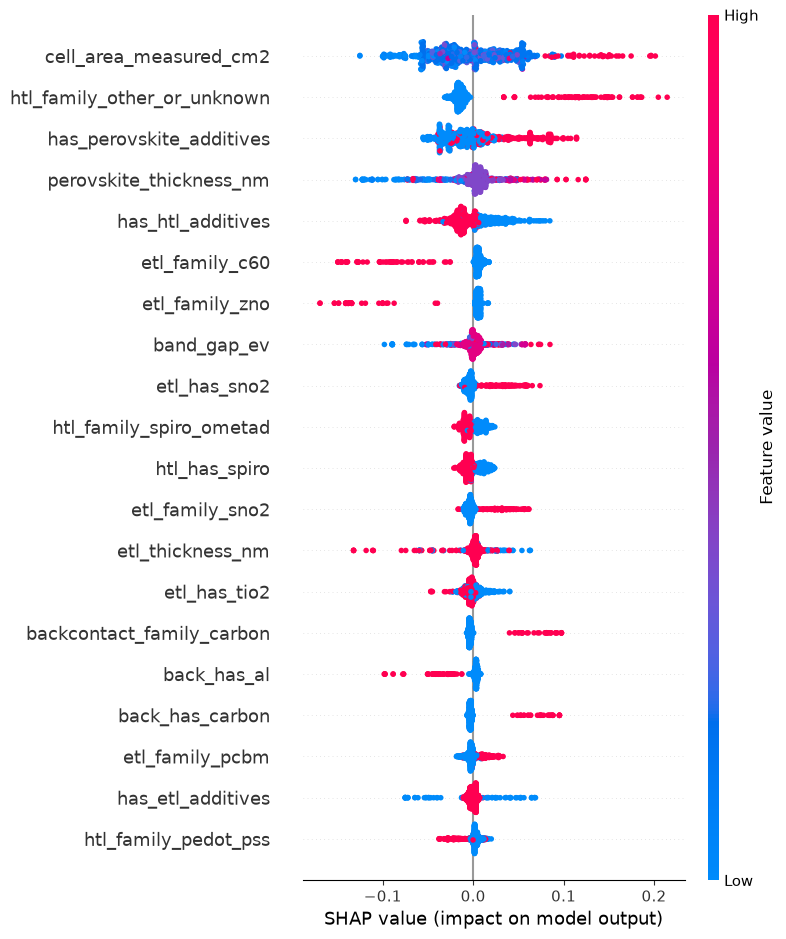

In [13]:
shap.summary_plot(shap_values, X_imp_df, show=True)

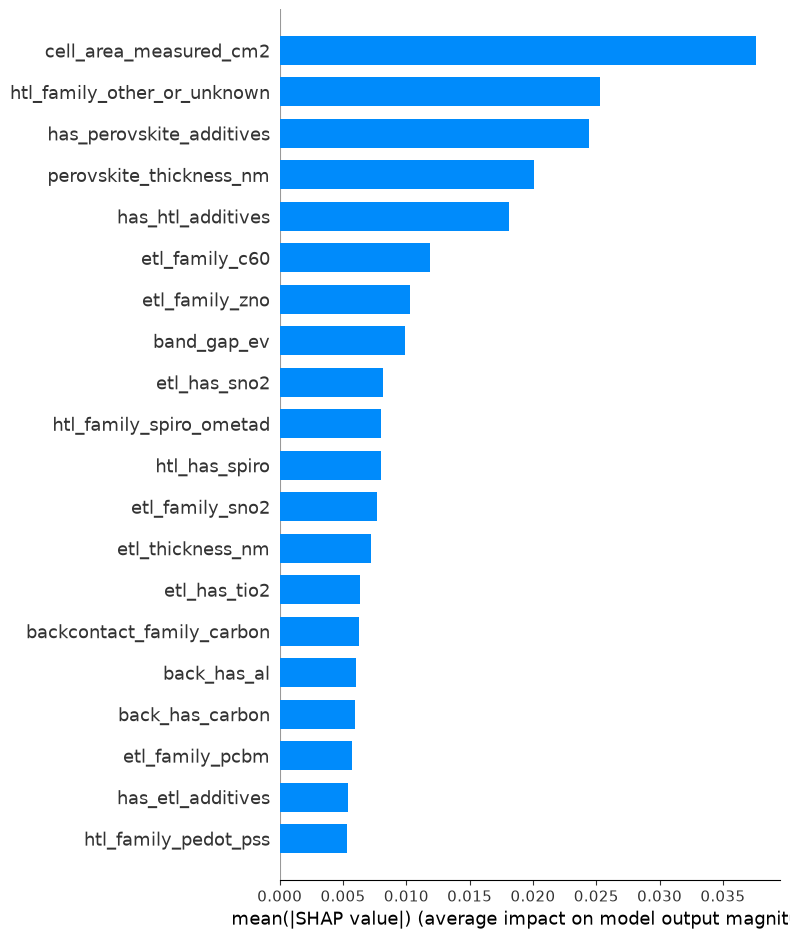

In [14]:
shap.summary_plot(shap_values, X_imp_df, plot_type="bar", show=True)

In [15]:
feature_groups = {}

for col in X_imp_df.columns:
    cl = col.lower()

    if any(k in cl for k in ["band_gap", "halide", "cation", "fa_", "ma_", "cs_", "br_", "i_", "cl_"]):
        feature_groups[col] = "composition"

    elif any(k in cl for k in ["perovskite_thickness", "etl_thickness", "htl_thickness", "thickness", "cell_area"]):
        feature_groups[col] = "device_structure"

    elif any(k in cl for k in ["etl_", "htl_", "back_", "backcontact_", "spiro", "ptaa", "pedot", "niox", "pcbm", "c60", "tio2", "sno2", "zno"]):
        feature_groups[col] = "transport_layers_contacts"

    elif any(k in cl for k in ["additive", "anneal", "process", "solvent", "temperature", "fabrication"]):
        feature_groups[col] = "processing"

    elif "missing" in cl:
        feature_groups[col] = "missingness_flags"

    else:
        feature_groups[col] = "other"

group_counts = pd.Series(feature_groups).value_counts()
print("Feature counts by domain:")
print(group_counts)

Feature counts by domain:
transport_layers_contacts    37
device_structure              3
processing                    1
composition                   1
other                         1
Name: count, dtype: int64


In [16]:
df_shap = pd.DataFrame(shap_values, columns=X_imp_df.columns)

domain_importance = {}

for col in X_imp_df.columns:
    domain = feature_groups[col]
    domain_importance.setdefault(domain, 0.0)
    domain_importance[domain] += np.abs(df_shap[col]).mean()

domain_df = pd.DataFrame({
    "domain": list(domain_importance.keys()),
    "importance": list(domain_importance.values())
}).sort_values("importance", ascending=False).reset_index(drop=True)

domain_df

,domain,importance
0,transport_layers_contacts,0.200803
1,device_structure,0.064951
2,processing,0.024456
3,composition,0.009871
4,other,0.001296


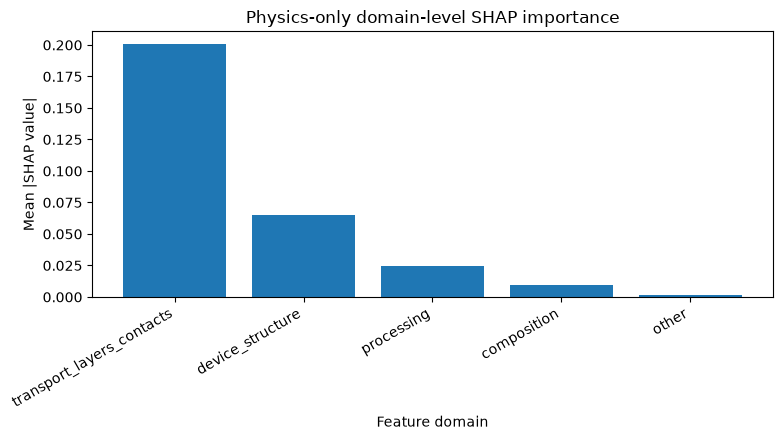

In [17]:
plt.figure(figsize=(8, 4.5))
plt.bar(domain_df["domain"], domain_df["importance"])
plt.title("Physics-only domain-level SHAP importance")
plt.ylabel("Mean |SHAP value|")
plt.xlabel("Feature domain")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [18]:
OUT_DIR = os.path.join(WORK_DIR, "artifacts", "08_physics_only")
os.makedirs(OUT_DIR, exist_ok=True)

compare_df.to_csv(os.path.join(OUT_DIR, "08_model_comparison.csv"), index=False)
domain_df.to_csv(os.path.join(OUT_DIR, "08_domain_importance.csv"), index=False)

feature_importance_df = pd.DataFrame({
    "feature": X_imp_df.columns,
    "mean_abs_shap": np.abs(df_shap).mean(axis=0).values,
    "domain": [feature_groups[c] for c in X_imp_df.columns]
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

feature_importance_df.to_csv(os.path.join(OUT_DIR, "08_feature_importance.csv"), index=False)

print("Saved:", os.path.join(OUT_DIR, "08_model_comparison.csv"))
print("Saved:", os.path.join(OUT_DIR, "08_domain_importance.csv"))
print("Saved:", os.path.join(OUT_DIR, "08_feature_importance.csv"))

feature_importance_df.head(20)

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\08_physics_only\08_model_comparison.csv
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\08_physics_only\08_domain_importance.csv
Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\08_physics_only\08_feature_importance.csv


,feature,mean_abs_shap,domain
0,cell_area_measured_cm2,0.037626,device_structure
1,htl_family_other_or_unknown,0.025269,transport_layers_contacts
2,has_perovskite_additives,0.024456,processing
3,perovskite_thickness_nm,0.020082,device_structure
4,has_htl_additives,0.018077,transport_layers_contacts
5,etl_family_c60,0.011880,transport_layers_contacts
6,etl_family_zno,0.010263,transport_layers_contacts
7,band_gap_ev,0.009871,composition
8,etl_has_sno2,0.008184,transport_layers_contacts
9,htl_family_spiro_ometad,0.008034,transport_layers_contacts


In [19]:
card = {
    "notebook": "08_physics_only_model.ipynb",
    "input_shape": {
        "rows": int(X_phys_cls.shape[0]),
        "cols": int(X_phys_cls.shape[1])
    },
    "baseline_feature_count": int(X_base_cls.shape[1]),
    "physics_only_feature_count": int(X_phys_cls.shape[1]),
    "removed_measurement_features": measurement_feature_cols,
    "target_design": "Extreme classification (25_75)",
    "architecture_removed": True,
    "top_domains": domain_df["domain"].tolist(),
    "top_10_features": feature_importance_df.head(10)["feature"].tolist()
}

card_path = os.path.join(OUT_DIR, "08_physics_only_card.json")
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=4)

print("Saved:", card_path)
print("DONE.")

Saved: C:\Users\khanm\OneDrive\Desktop\3rd model 18-03-2026\artifacts\08_physics_only\08_physics_only_card.json
DONE.
